# **EXPERIMENT-10** -Heart Dataset

**AIM:** Implement an Ensemble Learner using Adaboost Algorithm using Python programming.

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Step 2: Load dataset
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/Datasets/heart.csv')

print("shape:\n",df.shape)
print("\nFirst 2 rows:\n",df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shape:
 (1025, 14)

First 2 rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  


In [ ]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# Base model (Weak learner)
base_model = DecisionTreeClassifier(max_depth=1, random_state=42)

In [ ]:
# AdaBoost Model
ada = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

In [ ]:
# Predictions (Final Class Label)
y_pred = ada.predict(X_test)
print("\nFirst 10 Predicted Class Labels:\n", y_pred[:10])

# Class Probabilities
y_prob = ada.predict_proba(X_test)
print("\nFirst 10 Predicted Class Probabilities:\n", y_prob[:10])



First 10 Predicted Class Labels:
 [0 0 0 1 0 0 1 0 1 0]

First 10 Predicted Class Probabilities:
 [[0.64559088 0.35440912]
 [0.56638297 0.43361703]
 [0.69119666 0.30880334]
 [0.46623126 0.53376874]
 [0.55649005 0.44350995]
 [0.67995721 0.32004279]
 [0.4173427  0.5826573 ]
 [0.51809777 0.48190223]
 [0.33325182 0.66674818]
 [0.56638297 0.43361703]]


In [ ]:
# Show first 3 weak learner predictions without warnings
print("\nWeak Learner Weights (Alpha):")
print(ada.estimator_weights_)

for i, tree in enumerate(ada.estimators_[:3]):
    preds = tree.predict(X_test.values)  # <- convert DataFrame to numpy array
    print(f"Weak Learner {i+1} predictions (first 5 samples): {preds[:5]}")


Weak Learner Weights (Alpha):
[1.20555885 0.9698096  0.84950547 0.78367461 0.55182998 0.62688214
 0.29582201 0.36020637 0.47878653 0.30291796 0.40055776 0.45912263
 0.17211728 0.15351905 0.25958118 0.14185287 0.36220138 0.1810714
 0.31114161 0.22645893 0.28932518 0.21967998 0.09044613 0.14784797
 0.30846352 0.18976091 0.21331193 0.36181522 0.15630546 0.13389634
 0.17034825 0.16802665 0.24628502 0.13146722 0.07290306 0.12802843
 0.11045611 0.08032036 0.07612622 0.06035269 0.05843949 0.10928755
 0.15042316 0.11257206 0.05910065 0.07351199 0.18778914 0.16580654
 0.07148926 0.07495741]
Weak Learner 1 predictions (first 5 samples): [0 0 0 0 0]
Weak Learner 2 predictions (first 5 samples): [0 1 0 1 0]
Weak Learner 3 predictions (first 5 samples): [1 1 0 1 1]


In [ ]:
 # Manual weighted sum
weighted_sum = np.zeros(len(X_test))
for alpha, tree in zip(ada.estimator_weights_, ada.estimators_):
    preds = tree.predict(X_test.values)  # <- fix warning here
    preds_converted = np.where(preds == 0, -1, 1)
    weighted_sum += alpha * preds_converted

# Final decision
final_pred = np.where(weighted_sum > 0, 1, 0)
print("Manual weighted sum matches AdaBoost prediction:", np.all(final_pred == ada.predict(X_test)))

Manual weighted sum matches AdaBoost prediction: True


In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.8634146341463415

Confusion Matrix:
 [[82 18]
 [10 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.82      0.85       100
           1       0.84      0.90      0.87       105

    accuracy                           0.86       205
   macro avg       0.87      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205



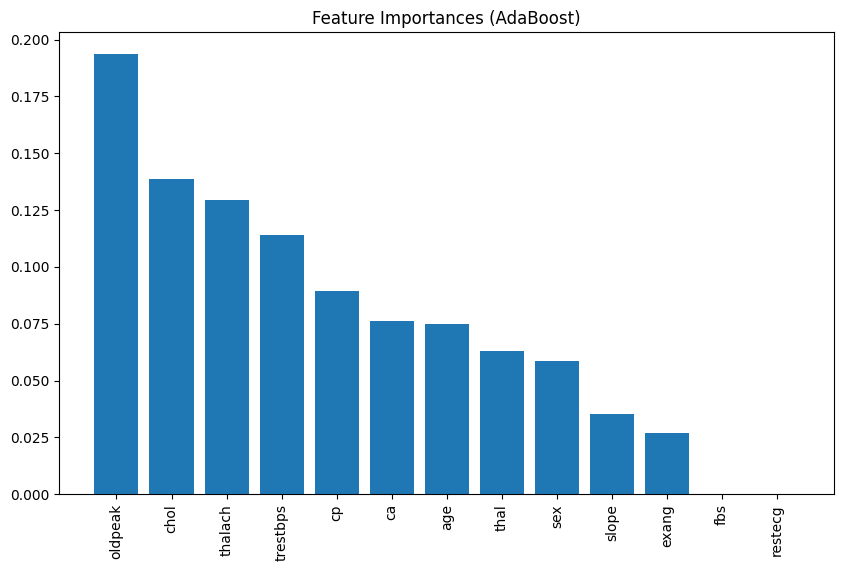

In [ ]:
importances = ada.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importances (AdaBoost)")
plt.show()